# Notebook: Find Matching Sentinel-2 Products for VHR Data

This notebook processes the VHR (Very High Resolution) catalog to find matching Sentinel-2 products based on spatial and temporal criteria. The goal is to identify S2 products that overlap with VHR acquisitions and have similar viewing angles.

Key steps:
- Analyze off-nadir angles in VHR data
- Filter VHR products by angle constraints
- Query Copernicus Data Space Ecosystem for matching S2 products
- Save candidate pairs to a Parquet file

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

from cdse_auth import get_access_token
from tqdm import tqdm
import pandas as pd
from pathlib import Path
import os

from helpers import query_s2_candidates

## Load and Analyze VHR Data

Load the joined VHR catalog and prepare for analysis.

In [2]:
PATH_DATA = "gpkg/vhr2024_joined_acq_catalog.gpkg"

In [3]:
vhr_gdf = gpd.read_file(PATH_DATA)

## Analyze Off-Nadir Angles

Examine the distribution of off-nadir angles across different providers and missions.

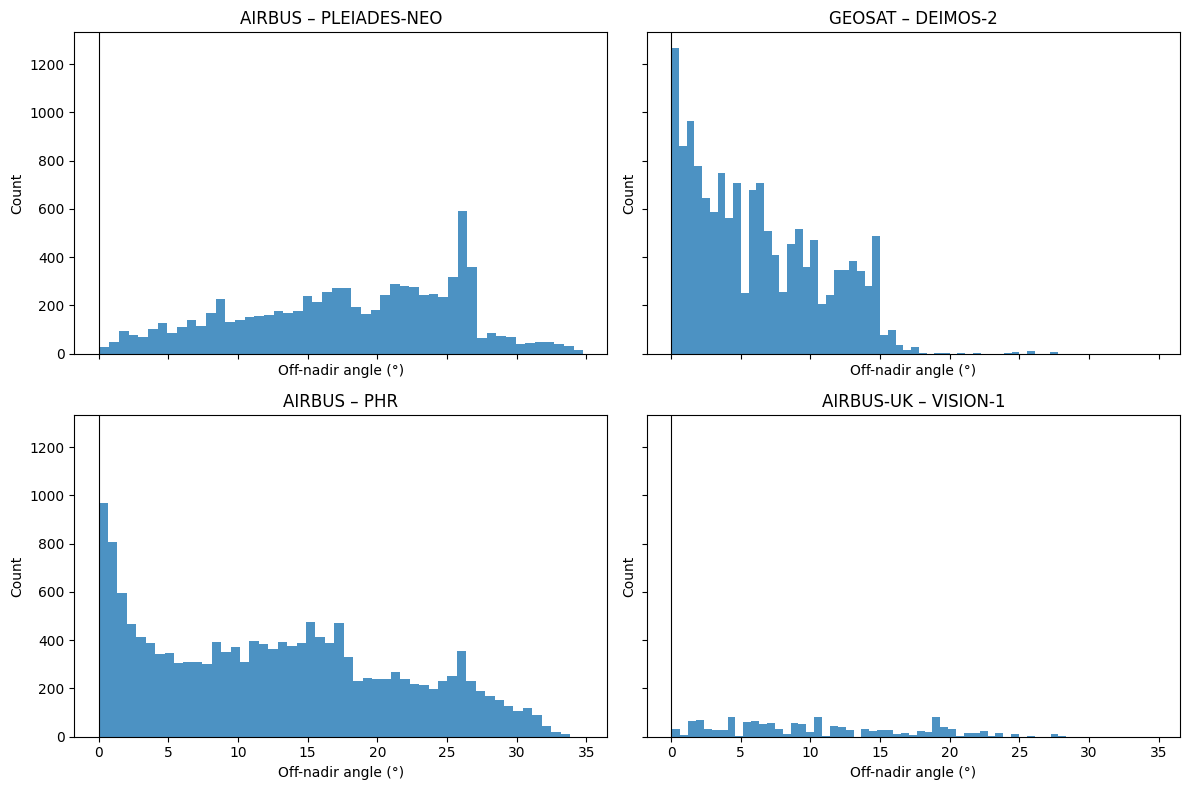

In [4]:
# Keep only rows with valid ona_angle
gdf = vhr_gdf[vhr_gdf["ona_angle"].notna()].copy()

# Get unique (provider, mission) pairs
pairs = vhr_gdf[["provider", "mission"]].drop_duplicates().reset_index(drop=True)

# ---- Plot ----
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (_, row) in zip(axes, pairs.iterrows()):
    provider = row["provider"]
    mission = row["mission"]

    subset = gdf[
        (gdf["provider"] == provider) &
        (gdf["mission"] == mission)
    ]

    ax.hist(
        subset["ona_angle"].abs(),
        bins=50,
        alpha=0.8
    )
    ax.set_title(f"{provider} – {mission}")
    ax.set_xlabel("Off-nadir angle (°)")
    ax.set_ylabel("Count")
    ax.axvline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()

In [5]:
# How many would pass various thresholds?
for th in [2, 4, 5, 6, 7, 8, 10, 12, 15]:
    n = (vhr_gdf["ona_angle"].abs() <= th).sum()
    print(f"ONA <= {th:>2}° : {n} / {len(vhr_gdf)} ({n/len(vhr_gdf)*100:.1f}%)")

ONA <=  2° : 6200 / 39693 (15.6%)
ONA <=  4° : 10187 / 39693 (25.7%)
ONA <=  5° : 12142 / 39693 (30.6%)
ONA <=  6° : 13709 / 39693 (34.5%)
ONA <=  7° : 15489 / 39693 (39.0%)
ONA <=  8° : 16996 / 39693 (42.8%)
ONA <= 10° : 20214 / 39693 (50.9%)
ONA <= 12° : 22886 / 39693 (57.7%)
ONA <= 15° : 27523 / 39693 (69.3%)


Note: The Sentinel-2 MSI sensor captures data with varying view zenith angles (VZA), typically from nadir (0°) out to about ±10.3° at the edge of its 290 km swath. 

## Filter by Off-Nadir Angle

Determine appropriate angle thresholds and filter VHR products accordingly.

In [11]:
MAX_ONA_DEG = 10.3 # Sentinel-2 has angles from -10.3° to +10.3°

vhr_ok = vhr_gdf[
    (vhr_gdf["ona_angle"].abs() <= MAX_ONA_DEG) &
    (vhr_gdf["acq_time"].notna())
].copy()

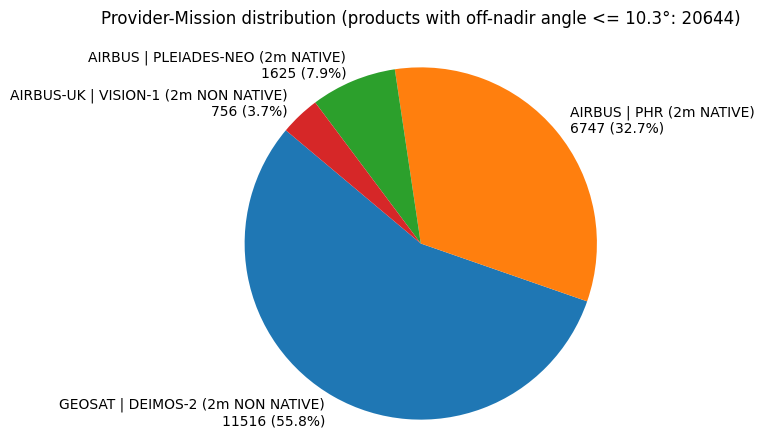

In [12]:
counts = (
    vhr_ok.groupby(["provider", "mission", "res_class"])
     .size()
     .sort_values(ascending=False)
)
total = counts.sum()

labels = [
    f"{prov} | {miss} ({res_class})\n{cnt} ({cnt/total*100:.1f}%)"
    for (prov, miss, res_class), cnt in counts.items()
]

plt.figure(figsize=(5, 5))
plt.pie(counts.values, labels=labels, startangle=140)
plt.title(f"Provider-Mission distribution (products with off-nadir angle <= {MAX_ONA_DEG}°: {total})", pad=20)
plt.axis("equal")  # keep circle shape
plt.show()

## Filter to Pleiades Mission

Focus on Pleiades (PHR) products for the matching process.

In [13]:
# Keep only the Pleiades Mission
vhr_ok = vhr_ok[vhr_ok["mission"] == "PHR"]

Note: At local scale (tangent-plane approximation), the off-nadir angle ($ONA$) and view zenith angle ($VZA$) coincide. On a spherical Earth they differ, with

$sin(VZA) = (1+ h/R)sin(ONA)$

where $R$ is Earth radius, $h$ is the satellite atlitude.

For Sentinel-2–like altitude and small viewing angles (~10°), the difference is on the order of ~1°.

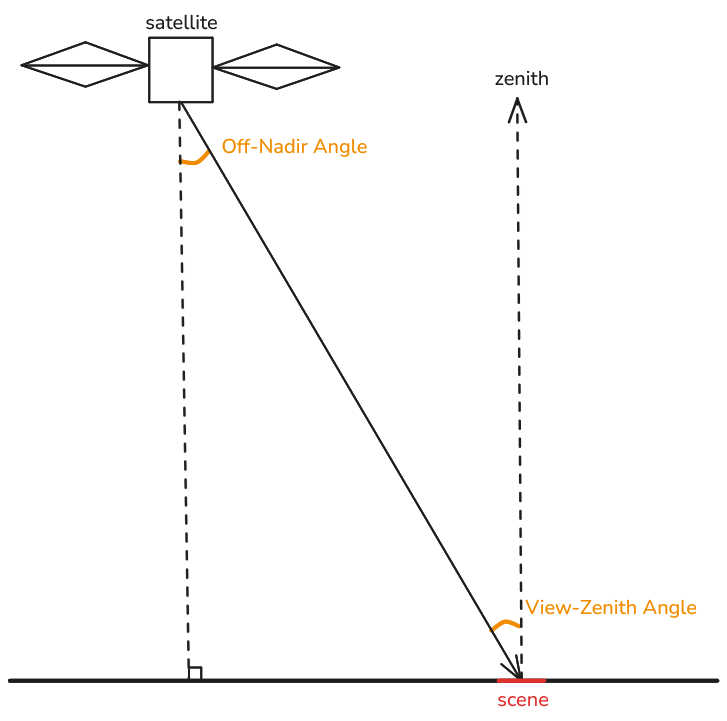


## Query S2 Candidates

Iterate through VHR products and query for matching Sentinel-2 products within spatial and temporal windows.

In [ ]:
token = get_access_token()

OUT_FILE = Path("parquet/s2_vhr_candidates_10deg.parquet").resolve()
TMP_FILE = OUT_FILE.with_suffix(".parquet.tmp")

SAVE_EVERY = 200  # save every N datastrips

# --- Resume: load existing results ---
if OUT_FILE.exists():
    existing = pd.read_parquet(OUT_FILE)
    done_datastrips = set(existing["datastrip"].unique())
    print(f"Resuming: {len(done_datastrips)} datastrips already done, {len(existing)} rows on disk.")
else:
    done_datastrips = set()
    print("Starting fresh: no existing parquet found.")

print("CWD:", os.getcwd())
print("OUT_FILE absolute:", OUT_FILE)
print("OUT_FILE exists:", OUT_FILE.exists())
print("done_datastrips:", len(done_datastrips))

buffer = []


def flush_buffer(buffer_rows):
    """Append buffer rows to parquet on disk, keeping old rows, then clear buffer."""
    if not buffer_rows:
        return

    df_chunk = pd.DataFrame(buffer_rows)

    if OUT_FILE.exists():
        df_prev = pd.read_parquet(OUT_FILE)
        df_all = pd.concat([df_prev, df_chunk], ignore_index=True)
    else:
        df_all = df_chunk

    # De-duplicate (datastrip + s2_id defines a unique pair)
    df_all = df_all.drop_duplicates(subset=["datastrip", "s2_id"])

    # Safer write: write temp then replace
    df_all.to_parquet(TMP_FILE, index=False)
    TMP_FILE.replace(OUT_FILE)

    buffer_rows.clear()


processed = 0
skipped = 0
no_candidates = 0

for _, row in tqdm(vhr_ok.iterrows(), total=len(vhr_ok), desc="Querying S2 candidates"):
    datastrip = row["datastrip"]

    # Resume skip (and also skips duplicates within this run)
    if datastrip in done_datastrips:
        skipped += 1
        continue

    aoi_geom = row.geometry
    t0 = pd.to_datetime(row["acq_time"], utc=True)

    try:
        s2_prods = query_s2_candidates(token, aoi_geom, t0, hours=12)
        if not s2_prods:
            no_candidates += 1
    except Exception:
        flush_buffer(buffer)
        raise

    for p in s2_prods:
        buffer.append({
            "datastrip": datastrip,
            "vhr_time": row["acq_time"],
            "ona_angle": row["ona_angle"],

            # Keep product_id too, since you need it for downloading VHR later
            "product_id": row.get("product_id"),
            "product_name": row.get("product_name"),

            "s2_id": p["Id"],
            "s2_name": p["Name"],
            "s2_time": p["ContentDate"]["Start"],
        })

    done_datastrips.add(datastrip)
    processed += 1

    # Periodic flush
    if processed % SAVE_EVERY == 0:
        flush_buffer(buffer)

# Final flush
flush_buffer(buffer)

print(f"Done. Processed={processed}, skipped(done/dup)={skipped}, no_candidates={no_candidates}. Saved to {OUT_FILE}")


Starting fresh: no existing parquet found.
CWD: c:\Users\tom\OneDrive - GeoCodis, informacijski sistemi, d.o.o\Documents\vhr_superres\src
OUT_FILE absolute: C:\Users\tom\OneDrive - GeoCodis, informacijski sistemi, d.o.o\Documents\vhr_superres\src\s2_vhr_candidates_10deg.parquet
OUT_FILE exists: False
done_datastrips: 0


Querying S2 candidates: 100%|██████████| 6747/6747 [36:44<00:00,  3.06it/s]  

Done. Processed=5216, skipped(done/dup)=1531, no_candidates=3305. Saved to C:\Users\tom\OneDrive - GeoCodis, informacijski sistemi, d.o.o\Documents\vhr_superres\src\s2_vhr_candidates_10deg.parquet
